In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [82]:
# 복잡한 데이터(차수가많은), 복잡한 모델(고차원모델), 적은데이터
# 과적합 방지
# 데이터 수 늘리기(현실적으로는 불가능), 복잡한 모델을단순화(히든레이어, 뉴런 줄이)
# 드랍아웃과 같은 별도의 규제레이어를 추가
# 학습일 잘되도록 하는 정규화 레이어를 추가

In [83]:
def create_complex_dataset(n_samples = 1200):
    X = torch.randn(n_samples,20)  # (1200,20)
    # 비선형  및 노이즈 추가
    y = (torch.sin(X[:, 0] * 2) + X[:, 1]**2 - torch.abs(X[:, 2]) + torch.randn(n_samples) * 0.1).reshape(-1, 1)
    # 정규화
    y = (y - y.mean()) / y.std()
    return TensorDataset(X,y)
dataset = create_complex_dataset()
train_size = int(0.8*len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset =  random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


# Early Stopping 클래스
 - 검증 손실이 개선되지 않을때 학습을 멈춤

In [84]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path = 'best_model.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best_loss = float('inf')
        self.eary_stop = False
        self.counter = 0
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            print(f'validation loss find { self.best_loss:.6f} model saved')
        else:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter}')
            if self.counter >= self.patience:
                self.eary_stop = True


# 모델정의(Dropout & Batch Normalization 적용)

In [85]:
x_batch, y_batch = next(iter(train_loader))
x_batch.shape,  y_batch.shape

(torch.Size([32, 20]), torch.Size([32, 1]))

In [86]:
class AdvancedModel(nn.Module):
    def __init__(self, input_dim,dropout_p = 0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어
            
            nn.Linear(128, 64),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어

            nn.Linear(64, 32),
            # 정규화 레이어
            nn.ReLU(),
            # 드랍아웃 레이어

            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)
    
model = AdvancedModel(input_dim=20)    
print(model)

AdvancedModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


# 학습루프(시각화)
- 옵티아미져,  손실함수 : 필수
- early stopping : 옵션

In [87]:
from tqdm import tqdm
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion =  nn.MSELoss()
early_stopping = EarlyStopping(patience=5)

epochs = 200
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))
for epoch in pbar:
    batch_train_losses = 0.0 ; batch_val_losses=0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()
    train_loss.append( batch_train_losses / len(train_loader) )
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            output = model(batch_x)
            loss = criterion(output, batch_y)
            batch_val_losses += loss.item()
        val_loss.append( batch_val_losses / len(val_loader) )
    pbar.set_postfix({'Train' : f'{train_loss[-1]:.4f}',  'val' : f'{val_loss[-1]:.4f}'})

    if (epoch+1) % 20 == 0 or epoch == 0:
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f}  val loss : {val_loss[-1]:.4f}')


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s, Train=0.9842, val=1.0237]

epoch 1 / 200 train loss : 0.9842  val loss : 1.0237


 10%|█         | 21/200 [00:02<00:21,  8.43it/s, Train=0.0211, val=0.1978]

epoch 20 / 200 train loss : 0.0241  val loss : 0.2129


...

epoch 160 / 200 train loss : 0.0025  val loss : 0.1427


 91%|█████████ | 182/200 [00:22<00:01, 13.84it/s, Train=0.0032, val=0.1405]

epoch 180 / 200 train loss : 0.0020  val loss : 0.1392


100%|██████████| 200/200 [00:23<00:00,  8.35it/s, Train=0.0061, val=0.1310]

epoch 200 / 200 train loss : 0.0061  val loss : 0.1310


# 시각화

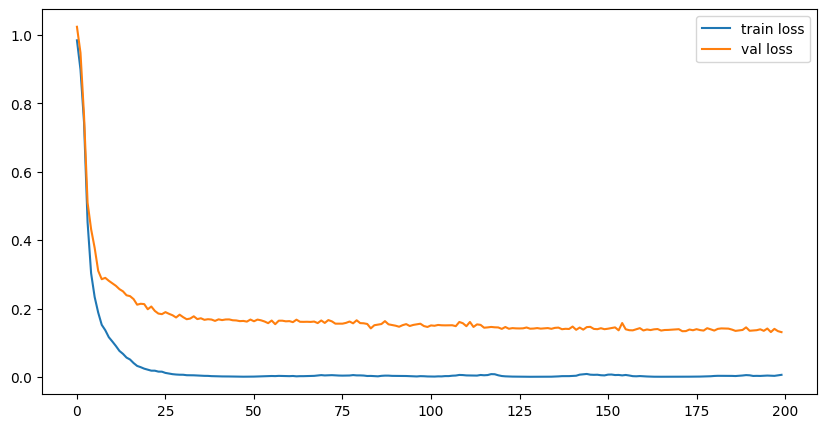

In [88]:
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(range(epochs), train_loss, label = 'train loss')
plt.plot(range(epochs), val_loss, label = 'val loss')
plt.legend()
plt.show()

# 규제(dropout) 정규화, ealy sotopping

In [89]:
new_layers = []
model = AdvancedModel(input_dim=20)
for i, layer in enumerate(list(model.network)):
    new_layers.append(layer)
    if isinstance(layer, nn.Linear) and i < len( list(model.network))-1:        
        new_layers.append(nn.BatchNorm1d( layer.out_features ))
    if isinstance(layer, nn.ReLU) :
        new_layers.append(nn.Dropout(0.5))
        

new_model = nn.Sequential(*new_layers)
new_model

Sequential(
  (0): Linear(in_features=20, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.5, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

torch.Size([240, 20])

In [ ]:
from tqdm import tqdm
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion =  nn.MSELoss()
early_stopping = EarlyStopping(patience=5)

epochs = 200
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))

val_loader = DataLoader(val_dataset, batch_size=len(val_dataset))

for epoch in pbar:
    new_model.train()  # 드랍아웃과 배치정규화가 학습 및 평가할때 서로 다르게 동작하는걸 방지
    batch_train_losses = 0.0 ; batch_val_losses=0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = new_model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()
    
    
        new_model.eval()
        with torch.no_grad(): # 불필요한 업데이트 방지(메모리 절약)
            for batch_x, batch_y in val_loader:
                output = new_model(batch_x)
                loss = criterion(output, batch_y)
                batch_val_losses += loss.item()
            val_loss.append( batch_val_losses / len(val_loader) )
            
    train_loss.append( batch_train_losses / len(train_loader) )
    pbar.set_postfix({'Train' : f'{train_loss[-1]:.4f}',  'val' : f'{val_loss[-1]:.4f}'})

    if (epoch+1) % 20 == 0 or epoch == 0:
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f}  val loss : {val_loss[-1]:.4f}')


  1%|          | 2/200 [00:00<00:33,  5.92it/s, Train=1.1755, val=1.0694]

epoch 1 / 200 train loss : 1.2268  val loss : 1.0866


 10%|█         | 20/200 [00:05<01:00,  2.97it/s, Train=0.7097, val=0.6472]

epoch 20 / 200 train loss : 0.7097  val loss : 0.6472


 20%|██        | 40/200 [00:12<00:46,  3.46it/s, Train=0.6125, val=0.4750]

...

epoch 160 / 200 train loss : 0.3669  val loss : 0.2924


 90%|█████████ | 181/200 [00:34<00:02,  8.26it/s, Train=0.4103, val=0.2861]

epoch 180 / 200 train loss : 0.4179  val loss : 0.3025


100%|██████████| 200/200 [00:36<00:00,  5.42it/s, Train=0.3958, val=0.2478]

epoch 200 / 200 train loss : 0.3958  val loss : 0.2478


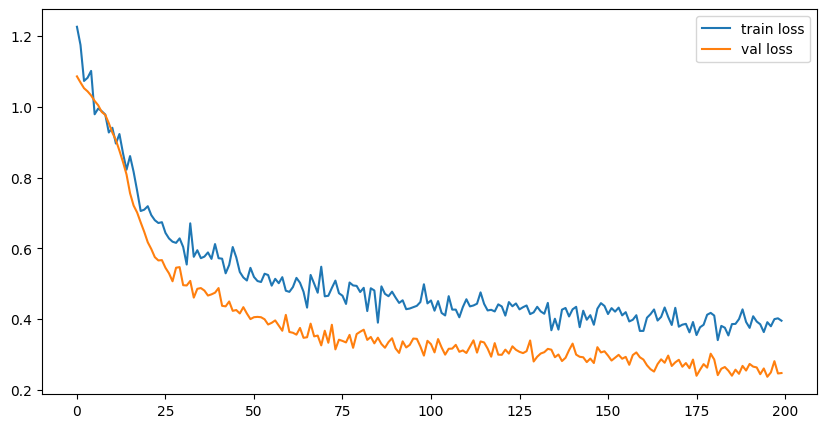

In [91]:
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(range(epochs), train_loss, label = 'train loss')
plt.plot(range(epochs), val_loss, label = 'val loss')
plt.legend()
plt.show()

In [ ]:
val_dataset

240

In [ ]:
val_dataset


(tensor([-0.7853, -0.2677, -2.3154, -0.0249,  1.4848,  0.9740, -0.7783,  0.6861,
         -0.3674, -0.3477,  0.8278, -0.2050,  1.5195, -0.8998, -0.3475,  1.1556,
         -1.2785, -0.8529, -0.5205, -0.2396]),
 tensor([-1.9928]))